<a href="https://colab.research.google.com/github/bnatsumi/calculo-numerico/blob/main/CN_atividade_pr%C3%A1tica_3_NB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática III - Zeros de funções
**Cálculo Numérico - UNIFESP** | Prof. Raquel J. Lobosco

Implementação dos métodos da bisseção, Newton e secante, aplicação nas funções $f_1$ a $f_4$ e animações do processo de aproximação.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# cores dos graficos
ROSA, ROSA_ESC, ROSA_CLR = "#E88AA6", "#B8506E", "#F7C6D4"
VERDE, VERDE_ESC, VERDE_CLR = "#8DB36B", "#5E8545", "#C9DDB2"
PESSEGO, PESSEGO_ESC = "#F4B183", "#C9773F"
CREME, TEXTO = "#FFF4E6", "#5B3A3A"
COR = {"Bisseção": VERDE_ESC, "Newton": ROSA_ESC, "Secante": PESSEGO_ESC}

plt.rcParams.update({
    "figure.facecolor": CREME, "axes.facecolor": "#FFFBF5", "axes.edgecolor": ROSA,
    "axes.labelcolor": TEXTO, "text.color": TEXTO, "xtick.color": TEXTO, "ytick.color": TEXTO,
    "axes.grid": True, "grid.color": "#F3D9E1", "grid.linestyle": "--", "font.size": 11,
})

## Parâmetros

Para testar outra função, outros valores iniciais, outra tolerância ou outro limite de iterações basta alterar a célula abaixo e rodar o notebook de novo.

In [27]:
TOL = 1e-6
MAX_ITER = 100
EPS = 1e-12   # derivada/denominador abaixo disso e considerado zero

FUNCOES = {
    "f1": dict(f=lambda x: x**2 - 2,       df=lambda x: 2*x,
               rotulo="x² − 2",      bissecao=(1, 2),   newton=1.5, secante=(1, 2),   janela=(0.6, 2.2)),
    "f2": dict(f=lambda x: x**3 - x - 2,   df=lambda x: 3*x**2 - 1,
               rotulo="x³ − x − 2",  bissecao=(1, 2),   newton=1.5, secante=(1, 2),   janela=(0.8, 2.1)),
    "f3": dict(f=lambda x: np.exp(-x) - x, df=lambda x: -np.exp(-x) - 1,
               rotulo="e⁻ˣ − x",     bissecao=(0, 1),   newton=0.5, secante=(0, 1),   janela=(-0.2, 1.2)),
    "f4": dict(f=lambda x: x**3 - 2*x + 2, df=lambda x: 3*x**2 - 2,
               rotulo="x³ − 2x + 2", bissecao=(-2, -1), newton=-2,  secante=(-2, -1), janela=(-2.3, -0.8)),
}

## Parte 1 - Implementação

**Critério de parada:** foi considerado que o método convergiu quando

$$|x_{k+1}-x_k| < \text{tol} \quad \text{e} \quad |f(x_{k+1})| < \text{tol}.$$

Usei as duas condições juntas porque só uma delas pode enganar: o passo pode ficar pequeno sem que $x$ esteja perto da raiz, e o resíduo pode ser pequeno se a função for muito achatada perto do zero. Na bisseção, a diferença entre aproximações foi medida pela meia-largura do intervalo, $(b-a)/2$.

Cada função retorna um dicionário com `raiz`, `iteracoes`, `aproximacoes`, `convergiu`, `mensagem` e `passos` (este último guarda os intervalos/retas de cada iteração para as animações).

In [28]:
def resultado(raiz, aprox, convergiu, msg, passos):
    return dict(raiz=raiz, iteracoes=len(aprox), aproximacoes=aprox,
                convergiu=convergiu, mensagem=msg, passos=passos)


def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    fa, fb = f(a), f(b)
    aprox, passos = [], []
    if fa * fb > 0:
        return resultado(None, aprox, False, "f(a)f(b) > 0", passos)

    for k in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)
        aprox.append(c)
        passos.append(dict(k=k, a=a, b=b, c=c, fc=fc))
        if fc == 0 or ((b - a) / 2 < tol and abs(fc) < tol):
            return resultado(c, aprox, True, "convergiu", passos)
        if fa * fc < 0:
            b = c
        else:
            a, fa = c, fc
    return resultado(c, aprox, False, "atingiu max_iter", passos)


def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER, eps=EPS):
    x = x0
    aprox, passos = [], []
    for k in range(1, max_iter + 1):
        fx, dfx = f(x), df(x)
        if abs(dfx) < eps:
            return resultado(x, aprox, False, "f'(x) ≈ 0", passos)
        x_novo = x - fx / dfx
        if not np.isfinite(x_novo):
            return resultado(x, aprox, False, "divergiu", passos)
        aprox.append(x_novo)
        passos.append(dict(k=k, x=x, fx=fx, dfx=dfx, x_novo=x_novo))
        if abs(x_novo - x) < tol and abs(f(x_novo)) < tol:
            return resultado(x_novo, aprox, True, "convergiu", passos)
        x = x_novo
    return resultado(x, aprox, False, "atingiu max_iter", passos)


def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER, eps=EPS):
    aprox, passos = [], []
    f0, f1 = f(x0), f(x1)
    for k in range(1, max_iter + 1):
        if abs(f1 - f0) < eps:
            return resultado(x1, aprox, False, "denominador ≈ 0", passos)
        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        if not np.isfinite(x2):
            return resultado(x1, aprox, False, "divergiu", passos)
        aprox.append(x2)
        passos.append(dict(k=k, x0=x0, x1=x1, f0=f0, f1=f1, x_novo=x2))
        f2 = f(x2)
        if abs(x2 - x1) < tol and abs(f2) < tol:
            return resultado(x2, aprox, True, "convergiu", passos)
        x0, f0, x1, f1 = x1, f1, x2, f2
    return resultado(x1, aprox, False, "atingiu max_iter", passos)

## Parte 2 - Aplicação e análise

In [29]:
def rodar(nome, metodo, ini=None):
    F = FUNCOES[nome]
    if metodo == "Bisseção":
        a, b = ini or F["bissecao"]
        return bissecao(F["f"], a, b), f"[{a}, {b}]"
    if metodo == "Newton":
        x0 = F["newton"] if ini is None else ini
        return newton(F["f"], F["df"], x0), f"x0 = {x0}"
    x0, x1 = ini or F["secante"]
    return secante(F["f"], x0, x1), f"({x0}, {x1})"


def linha(nome, metodo, res, ini):
    F, r = FUNCOES[nome], res["raiz"]
    return {"Função": f"{nome}(x) = {F['rotulo']}", "Método": metodo, "Valores iniciais": ini,
            "Raiz aproximada": "-" if r is None else f"{r:.10f}",
            "|f(x)| final": "-" if r is None else f"{abs(F['f'](r)):.2e}",
            "Iterações/resultado": f"{res['iteracoes']} - {res['mensagem']}"}


def estilo(df):
    fundo = {"Bisseção": "#EEF5E6", "Newton": "#FDEBF0", "Secante": "#FFF1E3"}
    return (df.style.apply(lambda l: [f"background-color:{fundo[l['Método']]}"] * len(l), axis=1)
              .set_table_styles([{"selector": "th", "props": f"background-color:{ROSA};color:white;"}])
              .hide(axis="index"))


resultados, linhas = {}, []
for nome in FUNCOES:
    for metodo in ("Bisseção", "Newton", "Secante"):
        res, ini = rodar(nome, metodo)
        resultados[(nome, metodo)] = res
        linhas.append(linha(nome, metodo, res, ini))

tabela = pd.DataFrame(linhas)
tabela.to_csv("tabela_resultados.csv", index=False)
display(estilo(tabela))

Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
f1(x) = x² − 2,Bisseção,"[1, 2]",1.4142136574,2.69e-07,21 - convergiu
f1(x) = x² − 2,Newton,x0 = 1.5,1.4142135624,4.44e-16,4 - convergiu
f1(x) = x² − 2,Secante,"(1, 2)",1.4142135624,8.88e-16,6 - convergiu
f2(x) = x³ − x − 2,Bisseção,"[1, 2]",1.5213797092,1.45e-08,22 - convergiu
f2(x) = x³ − x − 2,Newton,x0 = 1.5,1.5213797068,4.53e-14,3 - convergiu
f2(x) = x³ − x − 2,Secante,"(1, 2)",1.5213797068,1.84e-14,7 - convergiu
f3(x) = e⁻ˣ − x,Bisseção,"[0, 1]",0.5671434402,2.35e-07,20 - convergiu
f3(x) = e⁻ˣ − x,Newton,x0 = 0.5,0.5671432904,4.44e-15,3 - convergiu
f3(x) = e⁻ˣ − x,Secante,"(0, 1)",0.5671432904,1.24e-13,5 - convergiu
f4(x) = x³ − 2x + 2,Bisseção,"[-2, -1]",-1.7692923546,2.55e-09,21 - convergiu


In [30]:
# imagem da tabela para o dashboard
def tabela_png(df, arquivo="tabela_resultados.png"):
    fundo = {"Bisseção": "#EEF5E6", "Newton": "#FDEBF0", "Secante": "#FFF1E3"}
    fig, ax = plt.subplots(figsize=(13, 0.42 * (len(df) + 1) + 0.6))
    ax.axis("off")
    t = ax.table(cellText=df.values, colLabels=df.columns, loc="center", cellLoc="center")
    t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.55)
    for (i, j), cel in t.get_celld().items():
        cel.set_edgecolor("#F3D9E1")
        if i == 0:
            cel.set_facecolor(ROSA); cel.get_text().set_color("white"); cel.get_text().set_weight("bold")
        else:
            cel.set_facecolor(fundo[df.iloc[i - 1]["Método"]])
    ax.set_title("Tabela de resultados (tol = 1e-6, máx. 100 iterações)", color=ROSA_ESC, fontweight="bold")
    fig.savefig(arquivo, dpi=150, bbox_inches="tight", facecolor=CREME)
    plt.close(fig)

tabela_png(tabela)

### Testes com outros valores iniciais

Escolhi alguns valores para verificar se o código detecta as falhas:

- bisseção em $f_1$ com $[2,3]$: $f(2)=2$ e $f(3)=7$, sem troca de sinal;
- Newton em $f_1$ com $x_0=0$: $f'(0)=0$;
- secante em $f_1$ com $(-1,1)$: $f(-1)=f(1)$, denominador zero;
- Newton em $f_4$ com $x_0=0$: o método fica em ciclo entre 0 e 1.

In [31]:
extras = [("f1", "Bisseção", (2, 3)), ("f1", "Newton", 0),
          ("f1", "Secante", (-1, 1)), ("f4", "Newton", 0)]
linhas_extra = []
for nome, metodo, ini in extras:
    res, txt = rodar(nome, metodo, ini)
    resultados[(nome, metodo, str(ini))] = res
    linhas_extra.append(linha(nome, metodo, res, txt))
display(estilo(pd.DataFrame(linhas_extra)))

print("Newton em f4, x0 = 0:", resultados[("f4", "Newton", "0")]["aproximacoes"][:6])

Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
f1(x) = x² − 2,Bisseção,"[2, 3]",-,-,0 - f(a)f(b) > 0
f1(x) = x² − 2,Newton,x0 = 0,0.0000000000,2.00e+00,0 - f'(x) ≈ 0
f1(x) = x² − 2,Secante,"(-1, 1)",1.0000000000,1.00e+00,0 - denominador ≈ 0
f4(x) = x³ − 2x + 2,Newton,x0 = 0,0.0000000000,2.00e+00,100 - atingiu max_iter


Newton em f4, x0 = 0: [1.0, 0.0, 1.0, 0.0, 1.0, 0.0]


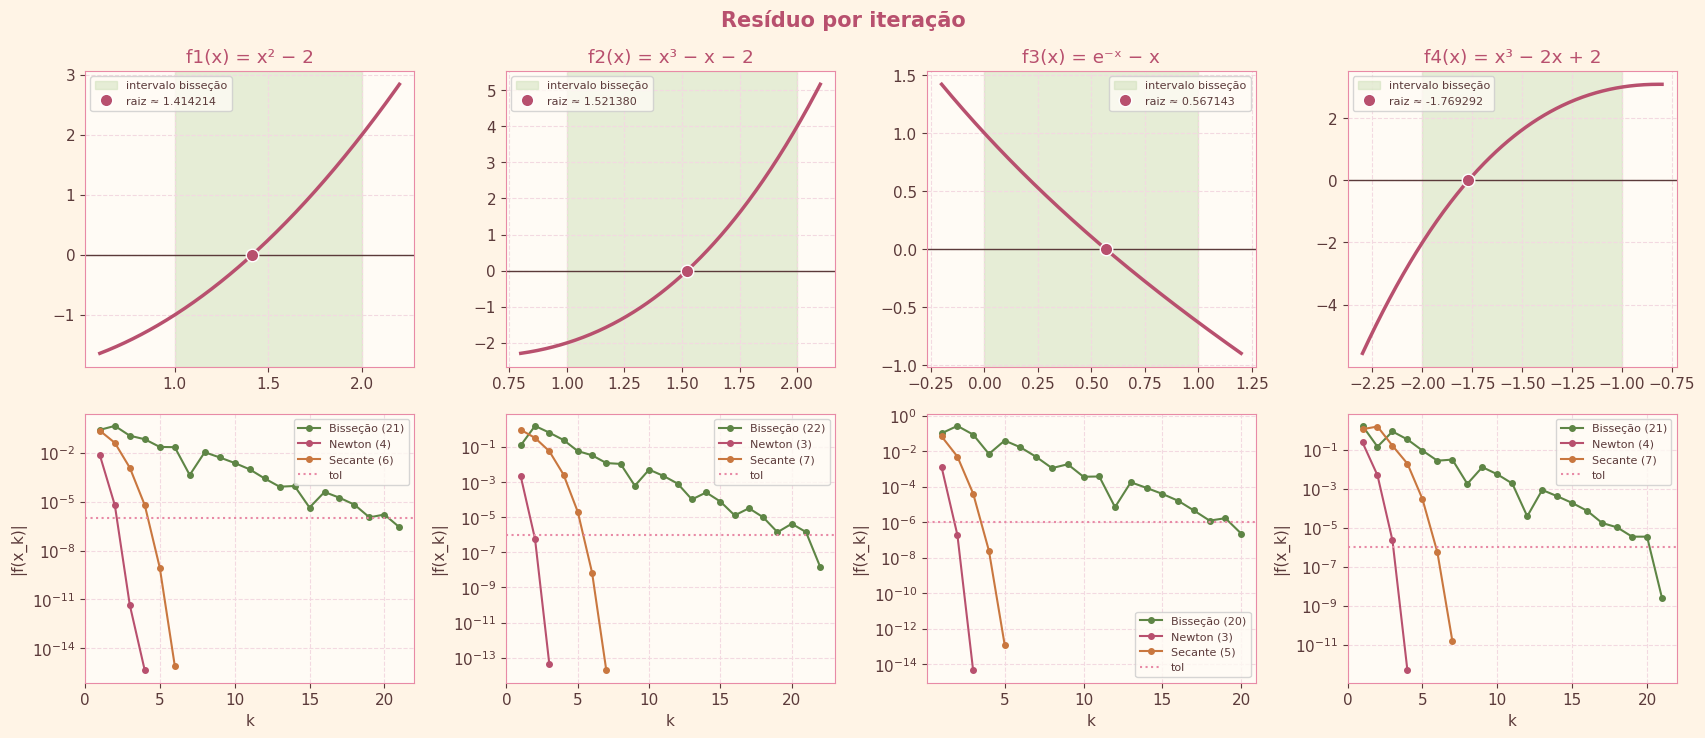

In [32]:
nomes = list(FUNCOES)
fig, axs = plt.subplots(2, 4, figsize=(17, 7.5), gridspec_kw=dict(height_ratios=[1.1, 1]))
for j, nome in enumerate(nomes):
    F = FUNCOES[nome]
    xs = np.linspace(*F["janela"], 400)
    ax = axs[0, j]
    ax.plot(xs, F["f"](xs), color=ROSA_ESC, lw=2.5)
    ax.axhline(0, color=TEXTO, lw=1)
    ax.axvspan(*F["bissecao"], color=VERDE_CLR, alpha=0.45, label="intervalo bisseção")
    r = resultados[(nome, "Newton")]["raiz"]
    ax.plot(r, 0, "o", ms=9, color=ROSA_ESC, mec="white", label=f"raiz ≈ {r:.6f}")
    ax.set_title(f"{nome}(x) = {F['rotulo']}", color=ROSA_ESC)
    ax.legend(fontsize=8)

    ax = axs[1, j]
    for metodo in ("Bisseção", "Newton", "Secante"):
        res = resultados[(nome, metodo)]
        resid = [max(abs(F["f"](x)), 1e-17) for x in res["aproximacoes"]]
        ax.semilogy(range(1, len(resid) + 1), resid, "o-", ms=4, color=COR[metodo],
                    label=f"{metodo} ({res['iteracoes']})")
    ax.axhline(TOL, color=ROSA, ls=":", label="tol")
    ax.set_xlabel("k"); ax.set_ylabel("|f(x_k)|"); ax.legend(fontsize=8)

fig.suptitle("Resíduo por iteração", fontsize=15, color=ROSA_ESC, fontweight="bold")
plt.tight_layout()
fig.savefig("painel_sintese.png", dpi=130, facecolor=CREME)
plt.show()

Com os valores sugeridos os três métodos convergiram para as mesmas raízes nas quatro funções. A bisseção precisou de 20 a 22 iterações (o número depende basicamente do tamanho do intervalo e da tolerância), o Newton de 3 a 4 e a secante de 5 a 7. No gráfico dá pra ver a diferença na ordem de convergência: o resíduo do Newton cai muito mais rápido, a secante fica no meio e a bisseção cai devagar e de forma irregular.

## Parte 3 - Animações

A função `animar` serve para qualquer combinação de função e método. Em cima aparece o gráfico de $f$ com o intervalo (bisseção), a reta tangente (Newton) ou a reta secante, e embaixo o resíduo $|f(x_k)|$ a cada iteração.

In [33]:
def animar(nome, metodo, res, arquivo, janela=None, max_quadros=22, fps=1.2, titulo=""):
    F = FUNCOES[nome]; f = F["f"]
    passos = res["passos"][:max_quadros]
    xa, xb = janela or F["janela"]
    xs = np.linspace(xa, xb, 500); ys = f(xs)
    m = 0.12 * (ys.max() - ys.min())
    ylim = (ys.min() - m, ys.max() + m)
    cor = COR[metodo]
    resid = [max(abs(f(p.get("c", p.get("x_novo")))), 1e-17) for p in passos]

    fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.2, 6.6), gridspec_kw=dict(height_ratios=[3, 1.25]))

    def quadro(i):
        k = min(i, len(passos) - 1)
        p = passos[k]
        ax.clear(); axr.clear()
        ax.plot(xs, ys, color=ROSA_ESC, lw=2.5, label="f(x)")
        ax.axhline(0, color=TEXTO, lw=1)

        if metodo == "Bisseção":
            x_at = p["c"]
            ax.axvspan(p["a"], p["b"], color=VERDE_CLR, alpha=0.55, label="[a, b]")
            ax.plot([p["a"], p["b"]], [f(p["a"]), f(p["b"])], "o", color=VERDE_ESC)
            ax.vlines(x_at, 0, p["fc"], color=VERDE_ESC, ls="--")
        elif metodo == "Newton":
            x_at = p["x_novo"]
            for q in passos[:k]:
                ax.plot(xs, q["fx"] + q["dfx"] * (xs - q["x"]), color=ROSA, lw=1, alpha=0.2)
            ax.plot(xs, p["fx"] + p["dfx"] * (xs - p["x"]), color=ROSA, lw=2, label="tangente")
            ax.plot(p["x"], p["fx"], "o", ms=8, color=ROSA_ESC)
            ax.vlines(x_at, 0, f(x_at), color=ROSA, ls=":")
        else:
            x_at = p["x_novo"]
            s = (p["f1"] - p["f0"]) / (p["x1"] - p["x0"])
            ax.plot(xs, p["f1"] + s * (xs - p["x1"]), color=PESSEGO_ESC, lw=2, label="secante")
            ax.plot([p["x0"], p["x1"]], [p["f0"], p["f1"]], "o", ms=8, color=PESSEGO_ESC)
            ax.vlines(x_at, 0, f(x_at), color=PESSEGO_ESC, ls=":")

        ax.plot(x_at, 0, "o", ms=10, color="#F2C14E", mec=ROSA_ESC, label="x_k")
        ax.set_xlim(xa, xb); ax.set_ylim(*ylim)
        ax.set_title(f"{metodo} - {nome}(x) = {F['rotulo']} {titulo}", color=ROSA_ESC)
        ax.legend(loc="upper left", fontsize=9)
        ax.text(0.97, 0.05, f"k = {p['k']}\nx_k = {x_at:.8f}\n|f(x_k)| = {abs(f(x_at)):.2e}",
                transform=ax.transAxes, ha="right", va="bottom", family="monospace",
                bbox=dict(boxstyle="round", fc=ROSA_CLR, ec=ROSA))

        axr.semilogy(range(1, k + 2), resid[:k + 1], "o-", color=cor)
        axr.axhline(TOL, color=ROSA, ls=":")
        axr.set_xlim(0.5, len(passos) + 0.5)
        axr.set_ylim(min(min(resid), TOL) / 10, max(resid) * 10)
        axr.set_xlabel("k"); axr.set_ylabel("|f(x_k)|")
        fig.tight_layout()

    anim = FuncAnimation(fig, quadro, frames=len(passos) + 4)
    anim.save(arquivo, writer=PillowWriter(fps=fps), dpi=90)
    plt.close(fig)
    display(Image(filename=arquivo))

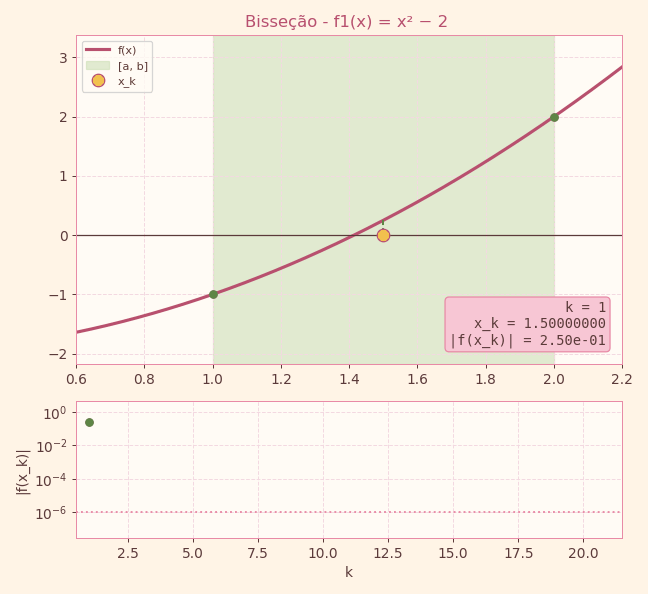

In [34]:
animar("f1", "Bisseção", resultados[("f1", "Bisseção")], "gif_bissecao_f1.gif")

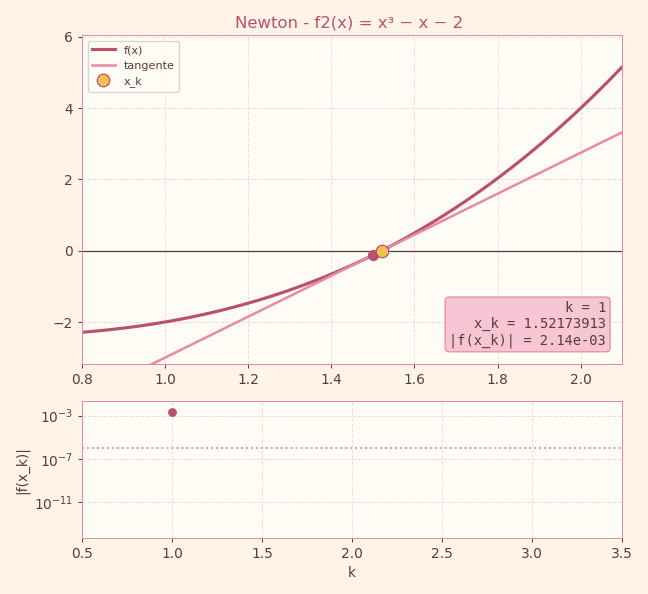

In [35]:
animar("f2", "Newton", resultados[("f2", "Newton")], "gif_newton_f2.gif", fps=0.9)

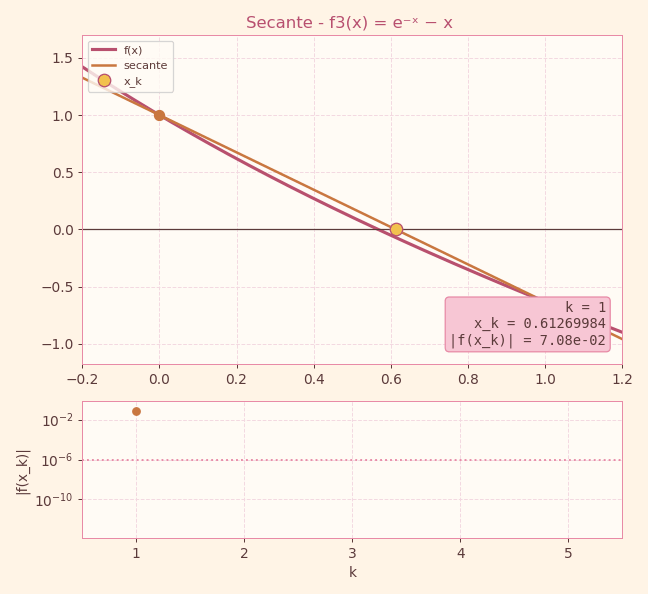

In [36]:
animar("f3", "Secante", resultados[("f3", "Secante")], "gif_secante_f3.gif", fps=0.9)

Por último, o Newton em $f_4$ com $x_0 = 0$, que entra em ciclo (0 → 1 → 0 → ...) e não converge. Com $x_0=-2$ o mesmo método converge em 4 iterações, então a escolha do valor inicial faz bastante diferença no Newton.

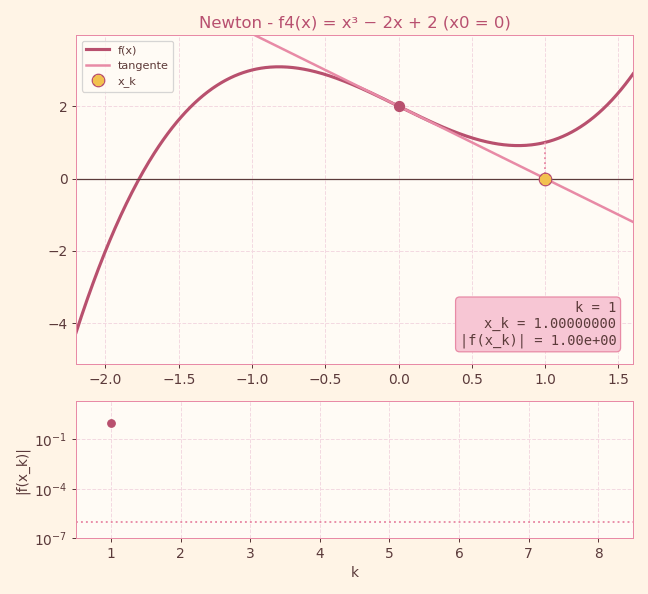

In [37]:
animar("f4", "Newton", resultados[("f4", "Newton", "0")], "gif_newton_f4_ciclo.gif",
       janela=(-2.2, 1.6), max_quadros=8, fps=0.9, titulo="(x0 = 0)")

## Conclusões

- A **bisseção** sempre converge se houver troca de sinal no intervalo, mas é a mais lenta (convergência linear, o erro cai pela metade a cada iteração).
- O **Newton** foi o mais rápido (convergência quadrática), mas precisa da derivada e depende do chute inicial: falha com $f'(x_k)=0$ e pode entrar em ciclo, como em $f_4$ com $x_0=0$.
- A **secante** não usa derivada e ainda assim converge bem mais rápido que a bisseção, mas também não tem garantia de convergência.

Raízes encontradas: $f_1$: 1,414214 · $f_2$: 1,521380 · $f_3$: 0,567143 · $f_4$: −1,769292.